# 江毅矿区 OD 区域聚类 v2：空间衍生特征 + OSM/资源图叠加

## 目标

将任务的起点（Origin）和终点（Destination）分别划分为空间作业区域，并构造可用于事前预测的区域与空间几何特征。

### 新增空间特征

- `od_longitude_diff_deg`：终点经度 - 起点经度
- `od_latitude_diff_deg`：终点纬度 - 起点纬度
- `od_midpoint_longitude`：起终点中点经度
- `od_midpoint_latitude`：起终点中点纬度
- `od_delta_east_m`：局部坐标下东西方向位移（m）
- `od_delta_north_m`：局部坐标下南北方向位移（m）

### OD 区域特征

- `start_zone_id`
- `end_zone_id`
- `od_zone_pair`
- `start_zone_distance_m`
- `end_zone_distance_m`

### 地图输出

参考 `OSMRouteForFilter.py`：

- OpenStreetMap Standard 底图；
- `MapResource.json` 中的资源区域/多边形；
- 资源车道/路径中心线；
- 起点聚类、终点聚类和 OD 区域流向；
- Folium 图层控制，可单独开关各图层。

### 设计原则

1. O、D 分开聚类；
2. 经纬度先转矿区局部米制坐标；
3. 严格按时间前 80% 拟合区域，后 20% 只做区域分配；
4. Ward 层次聚类作为主方法；
5. 测试/未来点通过最近训练区域中心获得 zone ID。


In [64]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

import folium

from sklearn.cluster import AgglomerativeClustering, Birch
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# ===== 绘图参数 =====
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "savefig.transparent": False,
    "text.color":         "black",
    "axes.edgecolor":     "black",
    "axes.labelcolor":    "black",
    "xtick.color":        "black",
    "ytick.color":        "black",
    "font.family":        "sans-serif",
    "font.sans-serif":    [
        "Microsoft YaHei", "SimHei", "SimSun",
        "Microsoft YaHei UI", "DejaVu Sans",
    ],
    "axes.unicode_minus": False,
    "legend.facecolor":   "white",
    "legend.edgecolor":   "#888888",
    "legend.labelcolor":  "black",
    "legend.framealpha":  1.0,
    "grid.alpha":         0.2,
    "grid.color":         "#cccccc",
    "axes.grid":          False,
    "axes.titlecolor":    "black",
})

TARGET_AREA = "TianChi"
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
DATA_FILE = PROJECT_ROOT / "data" / TARGET_AREA / f"任务特征和标签-{TARGET_AREA}.json"
RESOURCE_FILE = PROJECT_ROOT / "data" / TARGET_AREA / "MapResource.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / TARGET_AREA / "层次聚类结果"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.20
K_START = 6
K_END = 5

# 资源图过滤边界扩展；0.01 度约为 1 km 量级
RESOURCE_BBOX_MARGIN = 0.01
MAX_POINTS_PER_LANE = 300

print("数据文件：", DATA_FILE)
print("资源文件：", RESOURCE_FILE)
print("输出目录：", OUTPUT_DIR)


数据文件： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\任务特征和标签-TianChi.json
资源文件： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\MapResource.json
输出目录： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\层次聚类结果


In [65]:
with DATA_FILE.open("r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["actual_start_time"] = pd.to_datetime(
    df["actual_start_time"], format="mixed", errors="coerce"
)
df["actual_end_time"] = pd.to_datetime(
    df["actual_end_time"], format="mixed", errors="coerce"
)

required_geo = [
    "start_longitude", "start_latitude",
    "end_longitude", "end_latitude",
]
for col in required_geo:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["actual_start_time", *required_geo]).copy()
df = df.sort_values(
    ["actual_start_time", "actual_end_time", "task_id"]
).reset_index(drop=True)

# ============================================================
# 新增：起终点经纬度差 + 起终点中点经纬度
# 注意统一采用 “终点 - 起点” 的符号约定
# ============================================================
df["od_longitude_diff_deg"] = (
    df["end_longitude"] - df["start_longitude"]
)
df["od_latitude_diff_deg"] = (
    df["end_latitude"] - df["start_latitude"]
)
df["od_midpoint_longitude"] = (
    df["start_longitude"] + df["end_longitude"]
) / 2.0
df["od_midpoint_latitude"] = (
    df["start_latitude"] + df["end_latitude"]
) / 2.0

split_idx = int(len(df) * (1.0 - TEST_SIZE))
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("总样本数：", len(df))
print("训练样本数：", len(train_df))
print("测试样本数：", len(test_df))
print("训练时间范围：", train_df["actual_start_time"].min(), "至", train_df["actual_start_time"].max())
print("测试时间范围：", test_df["actual_start_time"].min(), "至", test_df["actual_start_time"].max())
print("新增角度空间特征：")
print([
    "od_longitude_diff_deg", "od_latitude_diff_deg",
    "od_midpoint_longitude", "od_midpoint_latitude"
])


总样本数： 3210
训练样本数： 2568
测试样本数： 642
训练时间范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:44:29.044000
测试时间范围： 2026-07-04 06:51:01.122000 至 2026-07-07 23:03:05.110000
新增角度空间特征：
['od_longitude_diff_deg', 'od_latitude_diff_deg', 'od_midpoint_longitude', 'od_midpoint_latitude']


## 1. 经纬度转矿区局部米制坐标

单矿区范围只有数公里，因此采用局部等距近似即可。坐标原点仅由训练集计算。

- `x_m`：东西方向相对位置
- `y_m`：南北方向相对位置


In [66]:
EARTH_RADIUS_M = 6_371_000.0

all_train_lon = pd.concat(
    [train_df["start_longitude"], train_df["end_longitude"]],
    ignore_index=True
)
all_train_lat = pd.concat(
    [train_df["start_latitude"], train_df["end_latitude"]],
    ignore_index=True
)

# 只利用训练数据确定局部坐标基准
LON0 = float(all_train_lon.mean())
LAT0 = float(all_train_lat.mean())
LAT0_RAD = math.radians(LAT0)

def lonlat_to_local_xy(lon, lat):
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    x = EARTH_RADIUS_M * np.radians(lon - LON0) * math.cos(LAT0_RAD)
    y = EARTH_RADIUS_M * np.radians(lat - LAT0)
    return np.column_stack([x, y])

def local_xy_to_lonlat(xy):
    xy = np.asarray(xy, dtype=float)
    lon = LON0 + np.degrees(
        xy[:, 0] / (EARTH_RADIUS_M * math.cos(LAT0_RAD))
    )
    lat = LAT0 + np.degrees(xy[:, 1] / EARTH_RADIUS_M)
    return np.column_stack([lon, lat])

X_start_train = lonlat_to_local_xy(
    train_df["start_longitude"], train_df["start_latitude"]
)
X_end_train = lonlat_to_local_xy(
    train_df["end_longitude"], train_df["end_latitude"]
)
X_start_test = lonlat_to_local_xy(
    test_df["start_longitude"], test_df["start_latitude"]
)
X_end_test = lonlat_to_local_xy(
    test_df["end_longitude"], test_df["end_latitude"]
)

# 新增：更适合模型使用、单位为米的东西/南北位移
train_df["od_delta_east_m"] = X_end_train[:, 0] - X_start_train[:, 0]
train_df["od_delta_north_m"] = X_end_train[:, 1] - X_start_train[:, 1]
test_df["od_delta_east_m"] = X_end_test[:, 0] - X_start_test[:, 0]
test_df["od_delta_north_m"] = X_end_test[:, 1] - X_start_test[:, 1]

print(f"局部坐标原点：lon0={LON0:.6f}, lat0={LAT0:.6f}")
print("新增米制位移特征：od_delta_east_m, od_delta_north_m")


局部坐标原点：lon0=89.262091, lat0=44.833966
新增米制位移特征：od_delta_east_m, od_delta_north_m


## 2. Ward 层次聚类：候选区域数

扫描 `k=2~12`，同时看：

- Silhouette score；
- 最小区域样本量；
- 空间图上的区域连续性；
- 区域是否具备真实作业区解释。

这一版固定：

- 起点区域 `K_START = 6`
- 终点区域 `K_END = 5`

这是为了避免仅追求最高 silhouette 而产生很小的碎片簇。


In [67]:
def scan_agglomerative_k(X, k_min=2, k_max=12):
    rows = []
    for k in range(k_min, k_max + 1):
        labels = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        ).fit_predict(X)
        counts = pd.Series(labels).value_counts()
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "min_cluster_n": int(counts.min()),
            "max_cluster_n": int(counts.max()),
        })
    return pd.DataFrame(rows)

start_k_table = scan_agglomerative_k(X_start_train)
end_k_table = scan_agglomerative_k(X_end_train)

print("起点候选 k：")
display(start_k_table.round(4))
print("终点候选 k：")
display(end_k_table.round(4))


起点候选 k：


,k,silhouette,min_cluster_n,max_cluster_n
0,2,0.6192,297,2271
1,3,0.4436,297,1197
2,4,0.4605,189,1197
3,5,0.5099,189,885
4,6,0.5031,169,885
5,7,0.4670,169,533
6,8,0.4623,137,533
7,9,0.4637,129,533
8,10,0.4906,129,503
9,11,0.5078,129,382


终点候选 k：


,k,silhouette,min_cluster_n,max_cluster_n
0,2,0.6959,252,2316
1,3,0.5233,252,1515
2,4,0.4495,252,1080
3,5,0.5065,252,801
4,6,0.4985,252,587
5,7,0.5175,137,587
6,8,0.5198,79,587
7,9,0.4711,79,493
8,10,0.4521,79,435
9,11,0.4301,79,435


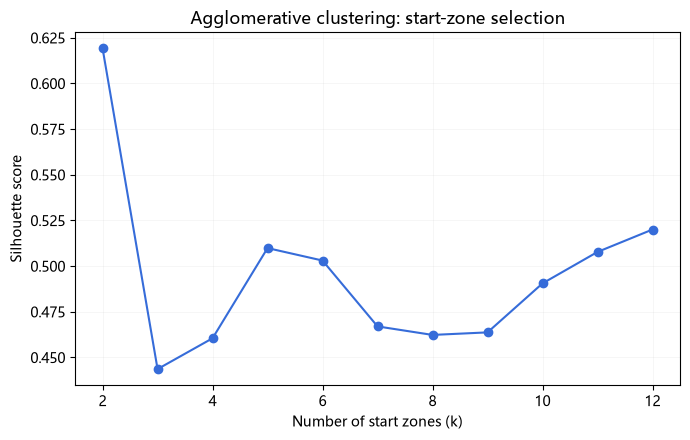

In [68]:
plt.figure(figsize=(7, 4.5))
plt.plot(
    start_k_table["k"],
    start_k_table["silhouette"],
    marker="o"
)
plt.xlabel("Number of start zones (k)")
plt.ylabel("Silhouette score")
plt.title("Agglomerative clustering: start-zone selection")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


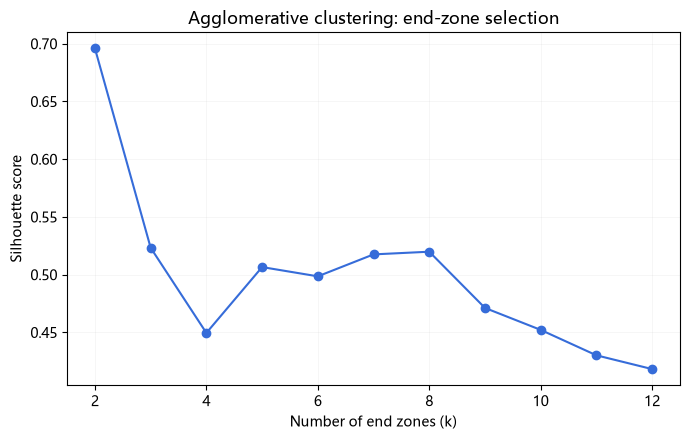

In [69]:
plt.figure(figsize=(7, 4.5))
plt.plot(
    end_k_table["k"],
    end_k_table["silhouette"],
    marker="o"
)
plt.xlabel("Number of end zones (k)")
plt.ylabel("Silhouette score")
plt.title("Agglomerative clustering: end-zone selection")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. 拟合固定 O/D 区域

层次聚类本身没有 `predict()`。因此：

1. 只在训练期拟合区域；
2. 计算每个区域的空间中心；
3. 测试/未来点分配到最近的训练区域中心；
4. 同时保留“到区域中心距离”，表示该任务位置是否典型。


In [70]:
def fit_agglomerative_zone(X_train, n_clusters):
    raw_labels = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    ).fit_predict(X_train)

    raw_centers = np.vstack([
        X_train[raw_labels == k].mean(axis=0)
        for k in range(n_clusters)
    ])

    # 使 zone 编号尽量具有空间稳定性
    order = np.lexsort((raw_centers[:, 1], raw_centers[:, 0]))
    remap = {old: new for new, old in enumerate(order)}
    labels = np.array([remap[x] for x in raw_labels], dtype=int)

    centers = np.vstack([
        X_train[labels == k].mean(axis=0)
        for k in range(n_clusters)
    ])
    return labels, centers

def assign_nearest_zone(X, centers):
    distance_matrix = np.sqrt(
        ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    )
    labels = distance_matrix.argmin(axis=1)
    distances = distance_matrix[
        np.arange(len(X)), labels
    ]
    return labels.astype(int), distances

start_train_zone, start_centers_xy = fit_agglomerative_zone(
    X_start_train, K_START
)
end_train_zone, end_centers_xy = fit_agglomerative_zone(
    X_end_train, K_END
)

_, start_train_dist = assign_nearest_zone(
    X_start_train, start_centers_xy
)
_, end_train_dist = assign_nearest_zone(
    X_end_train, end_centers_xy
)

start_test_zone, start_test_dist = assign_nearest_zone(
    X_start_test, start_centers_xy
)
end_test_zone, end_test_dist = assign_nearest_zone(
    X_end_test, end_centers_xy
)

print("起点训练区域样本量：")
print(pd.Series(start_train_zone).value_counts().sort_index())
print("\n终点训练区域样本量：")
print(pd.Series(end_train_zone).value_counts().sort_index())


起点训练区域样本量：
0    885
1    533
2    169
3    189
4    495
5    297
Name: count, dtype: int64

终点训练区域样本量：
0    252
1    493
2    587
3    435
4    801
Name: count, dtype: int64


In [71]:
def build_zone_table(labels, distances, centers_xy, prefix):
    centers_lonlat = local_xy_to_lonlat(centers_xy)
    rows = []
    for zone_id in range(len(centers_xy)):
        mask = labels == zone_id
        rows.append({
            "zone_id": zone_id,
            "n_train": int(mask.sum()),
            "center_longitude": float(centers_lonlat[zone_id, 0]),
            "center_latitude": float(centers_lonlat[zone_id, 1]),
            "median_radius_m": float(np.median(distances[mask])),
            "p90_radius_m": float(np.quantile(distances[mask], 0.90)),
            "max_radius_m": float(np.max(distances[mask])),
        })
    table = pd.DataFrame(rows)
    return table

start_zone_table = build_zone_table(
    start_train_zone, start_train_dist,
    start_centers_xy, "start"
)
end_zone_table = build_zone_table(
    end_train_zone, end_train_dist,
    end_centers_xy, "end"
)

print("起点区域中心：")
display(start_zone_table.round(3))
print("终点区域中心：")
display(end_zone_table.round(3))


起点区域中心：


,zone_id,n_train,center_longitude,center_latitude,median_radius_m,p90_radius_m,max_radius_m
0,0,885,89.276,44.833,107.537,223.798,284.273
1,1,533,89.276,44.836,114.193,198.516,226.670
2,2,169,89.278,44.837,85.773,120.691,137.791
3,3,189,89.280,44.829,122.011,197.731,240.912
4,4,495,89.281,44.835,129.474,242.961,401.006
5,5,297,89.287,44.828,183.495,278.768,379.994


终点区域中心：


,zone_id,n_train,center_longitude,center_latitude,median_radius_m,p90_radius_m,max_radius_m
0,0,252,89.240,44.831,46.128,70.280,292.158
1,1,493,89.245,44.835,54.215,87.385,147.588
2,2,587,89.245,44.834,58.307,80.743,99.254
3,3,435,89.247,44.835,45.235,72.800,92.542
4,4,801,89.248,44.836,101.491,139.817,328.247


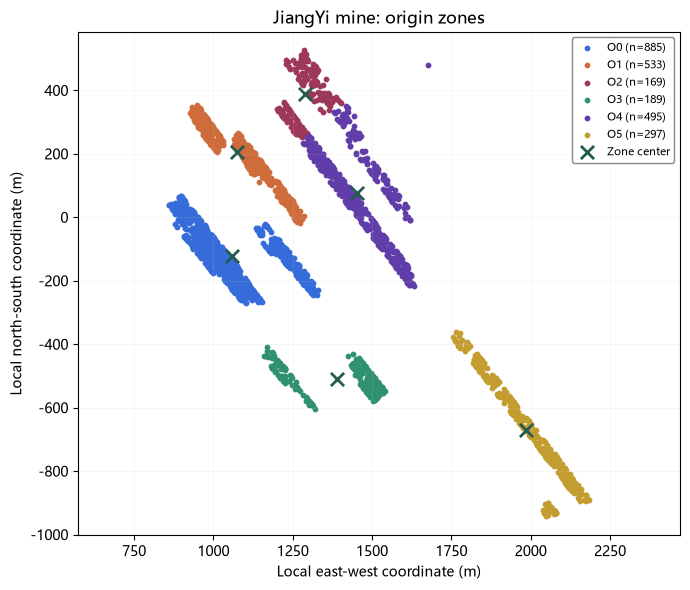

In [72]:
plt.figure(figsize=(7, 6))
for zone_id in sorted(np.unique(start_train_zone)):
    mask = start_train_zone == zone_id
    plt.scatter(
        X_start_train[mask, 0],
        X_start_train[mask, 1],
        s=10,
        label=f"O{zone_id} (n={mask.sum()})"
    )
plt.scatter(
    start_centers_xy[:, 0],
    start_centers_xy[:, 1],
    marker="x",
    s=90,
    linewidths=2,
    label="Zone center"
)
plt.xlabel("Local east-west coordinate (m)")
plt.ylabel("Local north-south coordinate (m)")
plt.title("JiangYi mine: origin zones")
plt.axis("equal")
plt.legend(fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


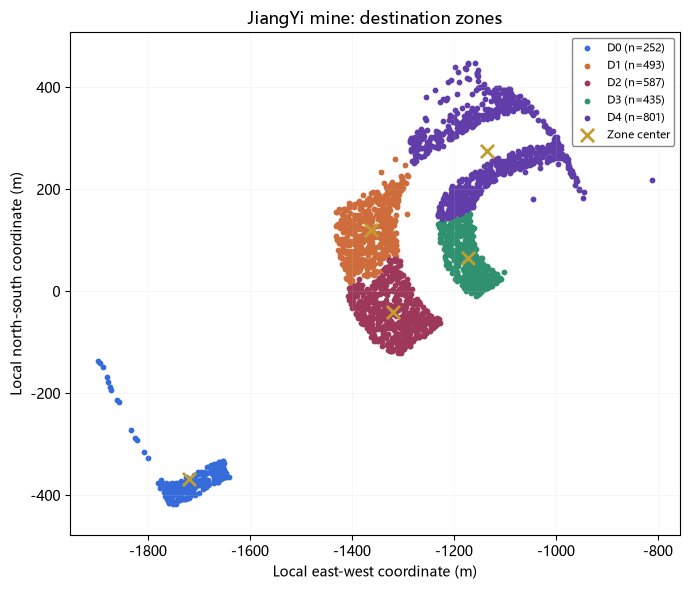

In [73]:
plt.figure(figsize=(7, 6))
for zone_id in sorted(np.unique(end_train_zone)):
    mask = end_train_zone == zone_id
    plt.scatter(
        X_end_train[mask, 0],
        X_end_train[mask, 1],
        s=10,
        label=f"D{zone_id} (n={mask.sum()})"
    )
plt.scatter(
    end_centers_xy[:, 0],
    end_centers_xy[:, 1],
    marker="x",
    s=90,
    linewidths=2,
    label="Zone center"
)
plt.xlabel("Local east-west coordinate (m)")
plt.ylabel("Local north-south coordinate (m)")
plt.title("JiangYi mine: destination zones")
plt.axis("equal")
plt.legend(fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. 截断层次树状图

完整树有 1592 个训练点，不适合作为论文图，因此只显示高层合并结构。


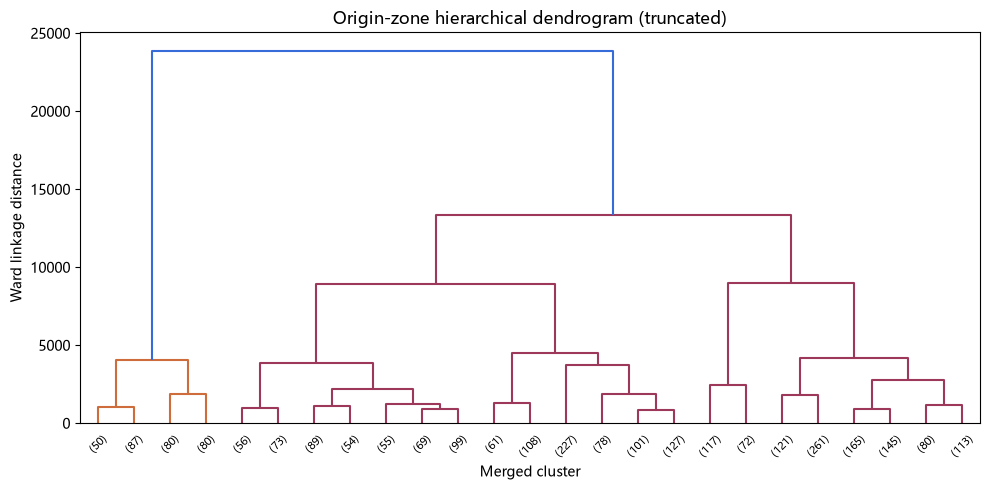

In [74]:
Z_start = linkage(X_start_train, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(
    Z_start,
    truncate_mode="lastp",
    p=25,
    show_leaf_counts=True,
    leaf_rotation=45,
    leaf_font_size=8,
)
plt.xlabel("Merged cluster")
plt.ylabel("Ward linkage distance")
plt.title("Origin-zone hierarchical dendrogram (truncated)")
plt.tight_layout()

plt.show()


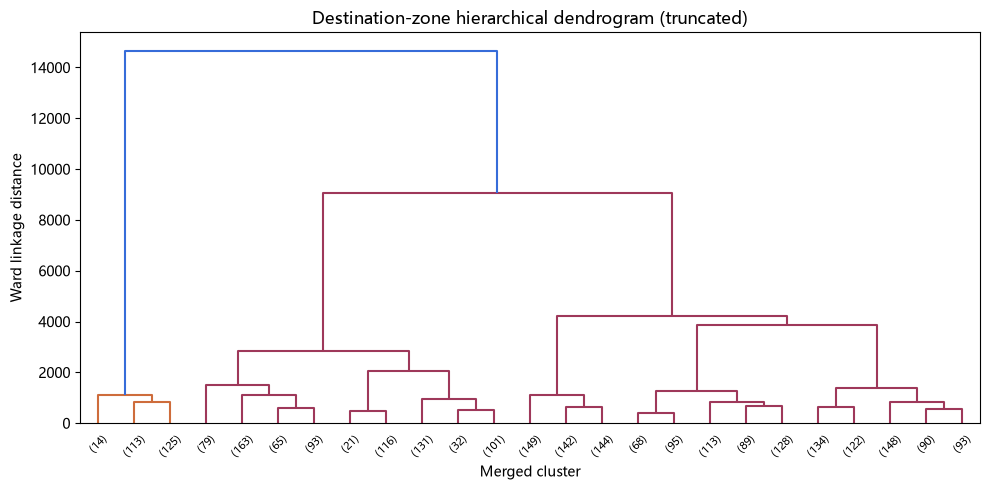

In [75]:
Z_end = linkage(X_end_train, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(
    Z_end,
    truncate_mode="lastp",
    p=25,
    show_leaf_counts=True,
    leaf_rotation=45,
    leaf_font_size=8,
)
plt.xlabel("Merged cluster")
plt.ylabel("Ward linkage distance")
plt.title("Destination-zone hierarchical dendrogram (truncated)")
plt.tight_layout()
plt.show()


## 5. 构造 OD 区域特征与空间几何特征

最终增强数据同时保留：

### 区域类别特征

- `start_zone_id`
- `end_zone_id`
- `od_zone_pair`

### 区域连续特征

- `start_zone_distance_m`
- `end_zone_distance_m`

### 空间几何特征

- `od_longitude_diff_deg`
- `od_latitude_diff_deg`
- `od_midpoint_longitude`
- `od_midpoint_latitude`
- `od_delta_east_m`
- `od_delta_north_m`

其中 `zone_id` / `od_zone_pair` 应视为类别变量；经纬度差、中点以及米制位移为连续变量。


In [76]:
train_enriched = train_df.copy()
test_enriched = test_df.copy()

train_enriched["start_zone_id"] = start_train_zone
train_enriched["end_zone_id"] = end_train_zone
train_enriched["od_zone_pair"] = (
    "O" + train_enriched["start_zone_id"].astype(str)
    + "_D" + train_enriched["end_zone_id"].astype(str)
)
train_enriched["start_zone_distance_m"] = start_train_dist
train_enriched["end_zone_distance_m"] = end_train_dist

test_enriched["start_zone_id"] = start_test_zone
test_enriched["end_zone_id"] = end_test_zone
test_enriched["od_zone_pair"] = (
    "O" + test_enriched["start_zone_id"].astype(str)
    + "_D" + test_enriched["end_zone_id"].astype(str)
)
test_enriched["start_zone_distance_m"] = start_test_dist
test_enriched["end_zone_distance_m"] = end_test_dist

enriched = pd.concat(
    [train_enriched, test_enriched],
    axis=0
).sort_values(
    ["actual_start_time", "actual_end_time", "task_id"]
).reset_index(drop=True)

pair_summary = (
    train_enriched["od_zone_pair"]
    .value_counts()
    .rename_axis("od_zone_pair")
    .reset_index(name="train_count")
)

display(pair_summary.head(20))


,od_zone_pair,train_count
0,O0_D4,245
1,O0_D3,241
2,O4_D4,172
3,O0_D0,161
4,O4_D2,161
5,O1_D4,158
6,O0_D2,137
7,O1_D3,115
8,O4_D1,114
9,O5_D4,108


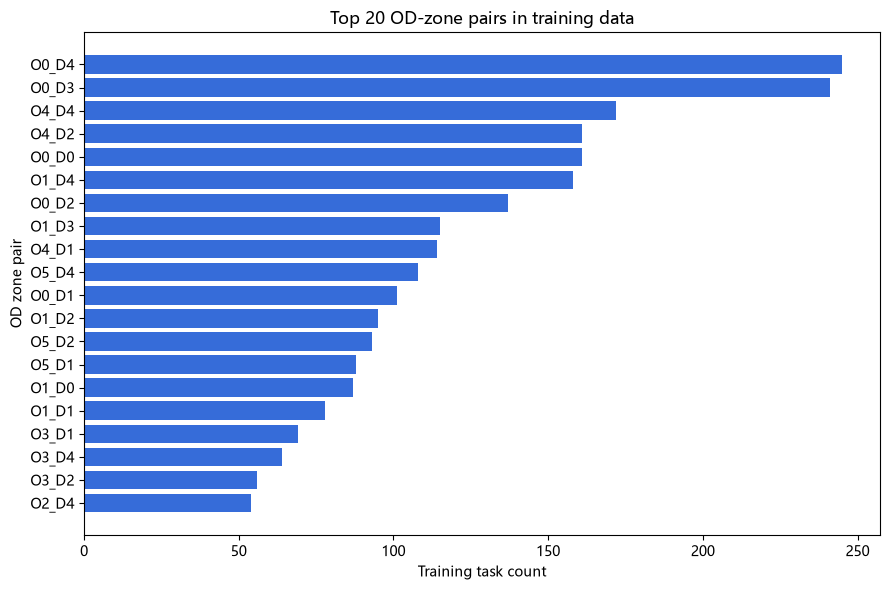

In [77]:
plt.figure(figsize=(9, 6))
top_pairs = pair_summary.head(20).sort_values(
    "train_count", ascending=True
)
plt.barh(
    top_pairs["od_zone_pair"],
    top_pairs["train_count"]
)
plt.xlabel("Training task count")
plt.ylabel("OD zone pair")
plt.title("Top 20 OD-zone pairs in training data")
plt.tight_layout()
plt.show()


## 6. OSM + MapResource 资源图上的 OD 聚类结果

本节参考 `OSMRouteForFilter.py` 的结构：

1. 使用 OpenStreetMap Standard 作为底图；
2. 读取 `MapResource.json`；
3. 叠加资源区域/多边形与车道/路径中心线；
4. 分别输出起点区域、终点区域、OD 流向三张交互 HTML 地图；
5. 地图中的所有图层都可通过右上角 LayerControl 开关。

> 如果当前环境找不到 `MapResource.json`，仍会生成 OSM + 聚类结果地图，同时给出 warning；在项目目录中运行且资源文件存在时，会自动叠加资源图。


In [78]:
# ============================================================
# 资源图解析：参考 OSMRouteForFilter.py
# ============================================================
def ensure_list(data):
    if isinstance(data, list):
        return data
    if isinstance(data, dict):
        return [data]
    raise ValueError(f"Unsupported JSON root type: {type(data)}")


def downsample(points, max_points):
    if len(points) <= max_points:
        return points
    step = math.ceil(len(points) / max_points)
    sampled = points[::step]
    if sampled[-1] != points[-1]:
        sampled.append(points[-1])
    return sampled


def bbox_from_points(point_groups):
    lats, lons = [], []
    for pts in point_groups:
        for lat, lon in pts:
            lats.append(float(lat))
            lons.append(float(lon))
    if not lats:
        raise ValueError("No points found")
    return min(lats), min(lons), max(lats), max(lons)


def point_in_bbox(lat, lon, bbox):
    south, west, north, east = bbox
    return south <= lat <= north and west <= lon <= east


def any_point_in_bbox(points, bbox):
    return any(point_in_bbox(lat, lon, bbox) for lat, lon in points)


def parse_point_list(point_list):
    """MapResource 中点格式通常为 {'x': lon, 'y': lat, 'z': alt}."""
    out = []
    if not isinstance(point_list, list):
        return out
    for p in point_list:
        if not isinstance(p, dict):
            continue
        x, y = p.get("x"), p.get("y")
        if x is None or y is None:
            continue
        out.append((float(y), float(x)))  # folium: (lat, lon)
    return out


def parse_resource_features(resource_file, filter_bbox):
    if not resource_file.exists():
        warnings.warn(
            f"未找到资源文件：{resource_file}。"
            "将生成 OSM + 聚类图，但不会显示矿区资源区域/车道。"
        )
        return [], []

    with resource_file.open("r", encoding="utf-8") as f:
        resources = ensure_list(json.load(f))

    polygons, lanes = [], []
    for item in resources:
        raw = item.get("数据")
        if not raw:
            continue
        try:
            data = json.loads(raw) if isinstance(raw, str) else raw
        except Exception:
            continue
        if not isinstance(data, dict):
            continue

        name = item.get("资源名称", "")
        rtype = item.get("资源类型", "")
        rid = item.get("资源类型ID", "")
        tooltip = f"{name} | {rtype} | 类型ID={rid}"

        poly_points = parse_point_list((data.get("polygon") or {}).get("point"))
        if len(poly_points) >= 3 and any_point_in_bbox(poly_points, filter_bbox):
            polygons.append({
                "name": name,
                "type": rtype,
                "type_id": rid,
                "tooltip": tooltip,
                "points": poly_points,
            })

        central_curve = data.get("central_curve") or {}
        segments = central_curve.get("segment") or []
        line_points = []
        for seg in segments:
            if not isinstance(seg, dict):
                continue
            line_seg = seg.get("line_segment") or {}
            pts = parse_point_list(line_seg.get("point"))
            if pts:
                if line_points and line_points[-1] == pts[0]:
                    line_points.extend(pts[1:])
                else:
                    line_points.extend(pts)

        if len(line_points) >= 2 and any_point_in_bbox(line_points, filter_bbox):
            lanes.append({
                "name": name,
                "type": rtype,
                "type_id": rid,
                "tooltip": tooltip,
                "raw_count": len(line_points),
                "points": downsample(line_points, MAX_POINTS_PER_LANE),
            })

    return polygons, lanes


def add_osm_standard_tile_layer(m):
    folium.TileLayer(
        tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
        attr="© OpenStreetMap contributors",
        name="OpenStreetMap Standard",
        overlay=False,
        control=True,
        show=True,
        max_zoom=19,
        min_zoom=0,
    ).add_to(m)


def add_resource_layers(m, polygons, lanes):
    fg_lanes = folium.FeatureGroup(
        name=f"资源车道/路径中心线（{len(lanes)}条）", show=False
    )
    fg_polygons = folium.FeatureGroup(
        name=f"资源区域/多边形（{len(polygons)}个）", show=True
    )

    for lane in lanes:
        folium.PolyLine(
            locations=lane["points"],
            weight=2,
            opacity=0.35,
            color="#555555",
            tooltip=lane["tooltip"],
        ).add_to(fg_lanes)

    color_by_type = {
        "HD换电站": "#1f77b4",
        "HD装料区": "#2ca02c",
        "HD装料位": "#2ca02c",
        "HD卸料位": "#ff7f0e",
        "HD排土场": "#9467bd",
        "HD均衡碾压区": "#d62728",
        "HD限速区": "#8c564b",
        "HD上下坡区": "#e377c2",
        "HD停车位": "#17becf",
    }
    for poly in polygons:
        color = color_by_type.get(poly["type"], "#3388ff")
        folium.Polygon(
            locations=poly["points"],
            color=color,
            weight=2,
            fill=True,
            fill_opacity=0.18,
            tooltip=poly["tooltip"],
        ).add_to(fg_polygons)

    fg_lanes.add_to(m)
    fg_polygons.add_to(m)


def make_base_cluster_map(all_points_latlon, polygons, lanes):
    south, west, north, east = bbox_from_points([all_points_latlon])
    center = [(south + north) / 2, (west + east) / 2]

    m = folium.Map(
        location=center,
        zoom_start=14,
        tiles=None,
        control_scale=True,
        prefer_canvas=True,
    )
    add_osm_standard_tile_layer(m)
    add_resource_layers(m, polygons, lanes)

    # OSM 瓦片加载慢时的底色
    css = """
    <style>
      .leaflet-container { background: #f4f1e8; }
      .leaflet-control-layers-expanded {
          max-height: 75vh;
          overflow-y: auto;
          min-width: 285px;
      }
    </style>
    """
    m.get_root().html.add_child(folium.Element(css))
    m.fit_bounds([[south, west], [north, east]])
    return m


In [79]:
# ============================================================
# 读取资源，并准备 zone 中心经纬度
# ============================================================
all_od_points = (
    list(zip(df["start_latitude"], df["start_longitude"]))
    + list(zip(df["end_latitude"], df["end_longitude"]))
)

south, west, north, east = bbox_from_points([all_od_points])
filter_bbox = (
    south - RESOURCE_BBOX_MARGIN,
    west - RESOURCE_BBOX_MARGIN,
    north + RESOURCE_BBOX_MARGIN,
    east + RESOURCE_BBOX_MARGIN,
)

resource_polygons, resource_lanes = parse_resource_features(
    RESOURCE_FILE, filter_bbox
)

start_centers_lonlat = local_xy_to_lonlat(start_centers_xy)  # [lon, lat]
end_centers_lonlat = local_xy_to_lonlat(end_centers_xy)

print(f"资源区域数量：{len(resource_polygons)}")
print(f"资源车道/路径数量：{len(resource_lanes)}")


资源区域数量：467
资源车道/路径数量：1067


In [80]:
# ============================================================
# 起点聚类：OSM + 资源图
# ============================================================
ZONE_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#a65628", "#f781bf", "#66c2a5", "#8da0cb", "#e78ac3",
    "#a6d854", "#d9a300",
]

origin_points = list(zip(df["start_latitude"], df["start_longitude"]))
m_origin = make_base_cluster_map(origin_points, resource_polygons, resource_lanes)

# 训练期 O 点
for zone_id in range(K_START):
    color = ZONE_COLORS[zone_id % len(ZONE_COLORS)]
    fg = folium.FeatureGroup(
        name=f"起点区域 O{zone_id}（训练）", show=True
    )
    mask = start_train_zone == zone_id
    rows = train_df.loc[mask]
    for _, row in rows.iterrows():
        folium.CircleMarker(
            location=[row["start_latitude"], row["start_longitude"]],
            radius=3,
            color=color,
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            tooltip=f"O{zone_id} | task={row['task_id']}",
        ).add_to(fg)
    fg.add_to(m_origin)

# 测试期 O 点：单独图层，默认关闭
fg_test_o = folium.FeatureGroup(name="测试期起点（按最近中心分区）", show=False)
for idx, (_, row) in enumerate(test_df.iterrows()):
    zone_id = int(start_test_zone[idx])
    color = ZONE_COLORS[zone_id % len(ZONE_COLORS)]
    folium.CircleMarker(
        location=[row["start_latitude"], row["start_longitude"]],
        radius=3,
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.35,
        tooltip=(
            f"test | O{zone_id} | task={row['task_id']} | "
            f"center_dist={start_test_dist[idx]:.1f} m"
        ),
    ).add_to(fg_test_o)
fg_test_o.add_to(m_origin)

# 区域中心
fg_centers_o = folium.FeatureGroup(name="起点区域中心", show=True)
for zone_id, (lon, lat) in enumerate(start_centers_lonlat):
    row = start_zone_table.loc[start_zone_table["zone_id"] == zone_id].iloc[0]
    folium.CircleMarker(
        location=[lat, lon],
        radius=9,
        color="#000000",
        weight=2,
        fill=True,
        fill_color=ZONE_COLORS[zone_id % len(ZONE_COLORS)],
        fill_opacity=1,
        tooltip=(
            f"O{zone_id} center | n={int(row['n_train'])} | "
            f"P90 radius={row['p90_radius_m']:.1f} m"
        ),
    ).add_to(fg_centers_o)
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:12px;font-weight:bold;color:black;">O{zone_id}</div>'
        ),
    ).add_to(fg_centers_o)
fg_centers_o.add_to(m_origin)

folium.LayerControl(collapsed=False).add_to(m_origin)
origin_map_file = OUTPUT_DIR / "origin_zones_OSM_MapResource.html"
m_origin.save(str(origin_map_file))
print("起点 OSM+资源聚类图：", origin_map_file)


起点 OSM+资源聚类图： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\层次聚类结果\origin_zones_OSM_MapResource.html


In [81]:
# ============================================================
# 终点聚类：OSM + 资源图
# ============================================================
destination_points = list(zip(df["end_latitude"], df["end_longitude"]))
m_dest = make_base_cluster_map(destination_points, resource_polygons, resource_lanes)

for zone_id in range(K_END):
    color = ZONE_COLORS[zone_id % len(ZONE_COLORS)]
    fg = folium.FeatureGroup(
        name=f"终点区域 D{zone_id}（训练）", show=True
    )
    mask = end_train_zone == zone_id
    rows = train_df.loc[mask]
    for _, row in rows.iterrows():
        folium.CircleMarker(
            location=[row["end_latitude"], row["end_longitude"]],
            radius=3,
            color=color,
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            tooltip=f"D{zone_id} | task={row['task_id']}",
        ).add_to(fg)
    fg.add_to(m_dest)

fg_test_d = folium.FeatureGroup(name="测试期终点（按最近中心分区）", show=False)
for idx, (_, row) in enumerate(test_df.iterrows()):
    zone_id = int(end_test_zone[idx])
    color = ZONE_COLORS[zone_id % len(ZONE_COLORS)]
    folium.CircleMarker(
        location=[row["end_latitude"], row["end_longitude"]],
        radius=3,
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.35,
        tooltip=(
            f"test | D{zone_id} | task={row['task_id']} | "
            f"center_dist={end_test_dist[idx]:.1f} m"
        ),
    ).add_to(fg_test_d)
fg_test_d.add_to(m_dest)

fg_centers_d = folium.FeatureGroup(name="终点区域中心", show=True)
for zone_id, (lon, lat) in enumerate(end_centers_lonlat):
    row = end_zone_table.loc[end_zone_table["zone_id"] == zone_id].iloc[0]
    folium.CircleMarker(
        location=[lat, lon],
        radius=9,
        color="#000000",
        weight=2,
        fill=True,
        fill_color=ZONE_COLORS[zone_id % len(ZONE_COLORS)],
        fill_opacity=1,
        tooltip=(
            f"D{zone_id} center | n={int(row['n_train'])} | "
            f"P90 radius={row['p90_radius_m']:.1f} m"
        ),
    ).add_to(fg_centers_d)
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:12px;font-weight:bold;color:black;">D{zone_id}</div>'
        ),
    ).add_to(fg_centers_d)
fg_centers_d.add_to(m_dest)

folium.LayerControl(collapsed=False).add_to(m_dest)
destination_map_file = OUTPUT_DIR / "destination_zones_OSM_MapResource.html"
m_dest.save(str(destination_map_file))
print("终点 OSM+资源聚类图：", destination_map_file)


终点 OSM+资源聚类图： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\层次聚类结果\destination_zones_OSM_MapResource.html


In [82]:
# ============================================================
# O-D 区域流向图：中心之间连线，线宽表示训练任务频次
# ============================================================
m_od = make_base_cluster_map(all_od_points, resource_polygons, resource_lanes)

fg_o_centers = folium.FeatureGroup(name="O 区域中心", show=True)
for zone_id, (lon, lat) in enumerate(start_centers_lonlat):
    folium.CircleMarker(
        location=[lat, lon],
        radius=9,
        color="#111111",
        weight=2,
        fill=True,
        fill_color=ZONE_COLORS[zone_id % len(ZONE_COLORS)],
        fill_opacity=1,
        tooltip=f"Origin O{zone_id}",
    ).add_to(fg_o_centers)
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:13px;font-weight:bold;">O{zone_id}</div>'
        ),
    ).add_to(fg_o_centers)
fg_o_centers.add_to(m_od)

fg_d_centers = folium.FeatureGroup(name="D 区域中心", show=True)
for zone_id, (lon, lat) in enumerate(end_centers_lonlat):
    folium.CircleMarker(
        location=[lat, lon],
        radius=9,
        color="#111111",
        weight=2,
        fill=True,
        fill_color=ZONE_COLORS[zone_id % len(ZONE_COLORS)],
        fill_opacity=1,
        tooltip=f"Destination D{zone_id}",
    ).add_to(fg_d_centers)
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:13px;font-weight:bold;">D{zone_id}</div>'
        ),
    ).add_to(fg_d_centers)
fg_d_centers.add_to(m_od)

# 从训练数据计算 O-D 频次
od_flow = (
    train_enriched.groupby(["start_zone_id", "end_zone_id"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
max_count = max(int(od_flow["count"].max()), 1)

fg_flow = folium.FeatureGroup(name="OD 区域流向（训练频次）", show=True)
for _, row in od_flow.iterrows():
    o = int(row["start_zone_id"])
    d = int(row["end_zone_id"])
    count = int(row["count"])

    o_lon, o_lat = start_centers_lonlat[o]
    d_lon, d_lat = end_centers_lonlat[d]

    # sqrt 缩放，避免头部 OD 组合把其它线完全压扁
    weight = 1.5 + 8.0 * math.sqrt(count / max_count)
    opacity = 0.35 + 0.55 * math.sqrt(count / max_count)

    folium.PolyLine(
        locations=[[o_lat, o_lon], [d_lat, d_lon]],
        color=ZONE_COLORS[o % len(ZONE_COLORS)],
        weight=weight,
        opacity=opacity,
        tooltip=f"O{o} → D{d} | training tasks={count}",
    ).add_to(fg_flow)
fg_flow.add_to(m_od)

folium.LayerControl(collapsed=False).add_to(m_od)

display(od_flow.head(20))


,start_zone_id,end_zone_id,count
4,0,4,245
3,0,3,241
22,4,4,172
20,4,2,161
0,0,0,161
9,1,4,158
2,0,2,137
8,1,3,115
19,4,1,114
26,5,4,108


In [83]:
# ============================================================
# 保存增强后的 JSON 与聚类元数据
# ============================================================
save_df = enriched.copy()

for col in ["actual_start_time", "actual_end_time"]:
    if col in save_df.columns:
        save_df[col] = save_df[col].apply(
            lambda x: x.strftime("%Y-%m-%d %H:%M:%S.%f")
            if pd.notna(x) else None
        )

records_out = json.loads(
    save_df.to_json(
        orient="records",
        force_ascii=False,
        date_format="iso"
    )
)

output_json = OUTPUT_DIR.parent / f"任务特征和标签-{TARGET_AREA}_层次聚类.json"
with output_json.open("w", encoding="utf-8") as f:
    json.dump(records_out, f, ensure_ascii=False, indent=2)

cluster_metadata = {
    "method": "AgglomerativeClustering-Ward + nearest-centroid assignment",
    "test_size": TEST_SIZE,
    "train_sample_count": int(len(train_df)),
    "test_sample_count": int(len(test_df)),
    "k_start": K_START,
    "k_end": K_END,
    "projection": {
        "type": "local_equirectangular",
        "lon0": LON0,
        "lat0": LAT0,
        "earth_radius_m": EARTH_RADIUS_M,
    },
    "added_spatial_features": [
        "od_longitude_diff_deg",
        "od_latitude_diff_deg",
        "od_midpoint_longitude",
        "od_midpoint_latitude",
        "od_delta_east_m",
        "od_delta_north_m",
    ],
    "added_zone_features": [
        "start_zone_id",
        "end_zone_id",
        "od_zone_pair",
        "start_zone_distance_m",
        "end_zone_distance_m",
    ],
    "map_resource_file": str(RESOURCE_FILE),
    "start_centers_xy_m": start_centers_xy.tolist(),
    "end_centers_xy_m": end_centers_xy.tolist(),
}

print("增强 JSON：", output_json)
print("新增空间特征：", cluster_metadata["added_spatial_features"])
print("新增区域特征：", cluster_metadata["added_zone_features"])


增强 JSON： C:\Users\14993\Desktop\新版\BoLei-DataMining\data\TianChi\任务特征和标签-TianChi_层次聚类.json
新增空间特征： ['od_longitude_diff_deg', 'od_latitude_diff_deg', 'od_midpoint_longitude', 'od_midpoint_latitude', 'od_delta_east_m', 'od_delta_north_m']
新增区域特征： ['start_zone_id', 'end_zone_id', 'od_zone_pair', 'start_zone_distance_m', 'end_zone_distance_m']
